# Density Estimation

## Roadmap

1. Create a kernel density estimator $\hat{f}_h(x)$
2. Implement the Silverman plug-in bandwidth $h$
3. Contrast the KDE's small sample properties with the ECDF's small sample properties

## Estimating $f(x)$
- Intuitively, we are estimating the "probability" that $X$ lands in a small neighborhood around $x$, $ x-h < X < x+h $
- The corresponding sample question is, "What is the sample proportion of observations in a neighborhood, from $x-h$ to $x+h$?"
- We call that $h$ the **bandwidth**
- This is a "moving window histogram" called a **kernel density estimator**

## Example: Heart Failure and Age

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [116]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

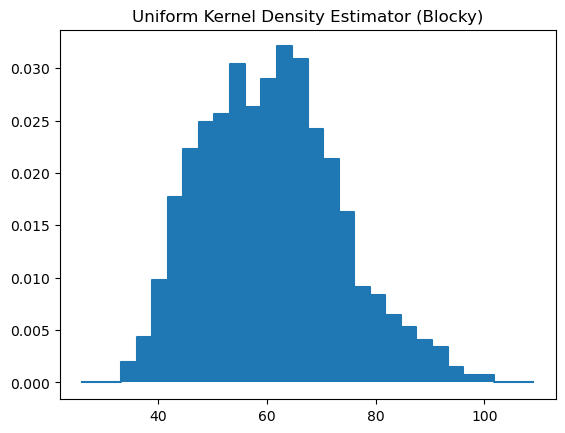

(array([ 26.02526458,  28.88559116,  31.74591774,  34.60624432,
         37.4665709 ,  40.32689748,  43.18722406,  46.04755064,
         48.90787722,  51.7682038 ,  54.62853039,  57.48885697,
         60.34918355,  63.20951013,  66.06983671,  68.93016329,
         71.79048987,  74.65081645,  77.51114303,  80.37146961,
         83.2317962 ,  86.09212278,  88.95244936,  91.81277594,
         94.67310252,  97.5334291 , 100.39375568, 103.25408226,
        106.11440884, 108.97473542]),
 array([0.        , 0.        , 0.        , 0.00191459, 0.00430782,
        0.00981226, 0.01770993, 0.02225708, 0.02488964, 0.02560761,
        0.03039408, 0.02632558, 0.02895813, 0.03206934, 0.03087272,
        0.02417167, 0.02129979, 0.01627399, 0.00909429, 0.00837632,
        0.00646173, 0.00526512, 0.0040685 , 0.00335053, 0.00143594,
        0.00071797, 0.00071797, 0.        , 0.        , 0.        ]))

In [117]:
kde(df['age'])

[Text(0.5, 1.0, 'Gaussian KDE (Smooth)')]

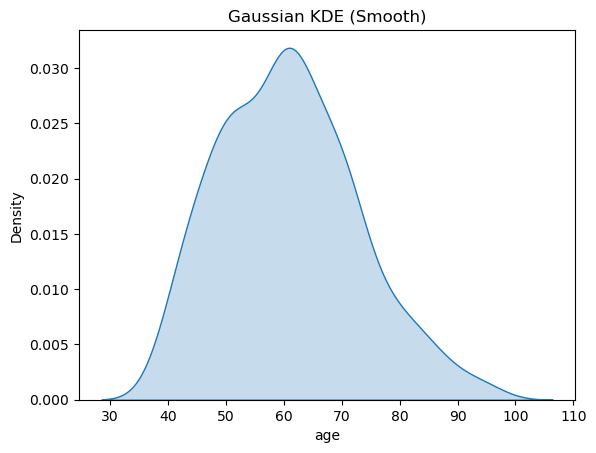

In [118]:
sns.kdeplot( data = df, x = 'age', fill = True).set(title='Gaussian KDE (Smooth)')

## 1. Estimating the PDF
- The pdf at $x$ is roughly, "The probability that $X$ falls in a window around $x$, as the window/bandwidth $h$ shrinks"
- Let's estimate that with: "The sample proportion of observations in a window of length $2h$ around $x$, as the bandwidth goes to zero",
$$
\hat{f}(x) = \dfrac{\text{ Number of observations $i$ within $\pm h$ of $x$} }{n \times 2h} 
$$
- This gives us something like a histogram, called a **(uniform) kernel density estimator**:
$$
\hat{f}_h(x) = \frac{ \sum_{i=1}^n  \mathbb{I}\{ |x_i-x|<h \} }{2nh}
$$
- Why $2h$? The length of the interval $(x-h, x+h)$ is $x-h-(x-h)=2h$, and we divide to normalize the "width" of the window to 1

## Example

- Build a KDE estimator for the data `[.5, .7, 1]` with `h=.25`
- Build a KDE estimator for the data `[1, 1.5, 2, 2.5, 3]` with `h=.6`

## 2. Plug-in Bandwidth
- There are data-driven methods to pick the bandwidth $h$ (likelihood or least squares cross validation), there is a standard and convenient choice called **Silverman's rule-of-thumb (for the uniform kernel)**:
$$
h_u = 1.84 \times \text{sd}(X) \times n^{-1/5},
$$
- We do want to investigate different choices of $h$, but having a standard starting point is very, very convenient

## Example: Ejection Fraction

In [131]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    print(f'Plug-in Bandwidth Estimated is: {h_u:2f}')
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.show()
    return x_grid, f_hat

Plug-in Bandwidth Estimated is: 6.952141


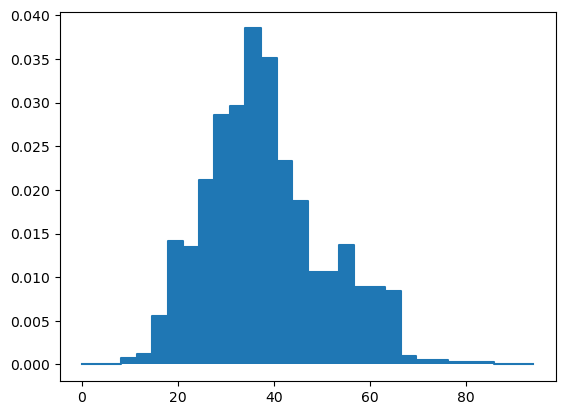

(array([ 0.09571897,  3.33049697,  6.56527498,  9.80005298, 13.03483098,
        16.26960898, 19.50438698, 22.73916499, 25.97394299, 29.20872099,
        32.44349899, 35.67827699, 38.913055  , 42.147833  , 45.382611  ,
        48.617389  , 51.852167  , 55.086945  , 58.32172301, 61.55650101,
        64.79127901, 68.02605701, 71.26083501, 74.49561302, 77.73039102,
        80.96516902, 84.19994702, 87.43472502, 90.66950303, 93.90428103]),
 array([0.        , 0.        , 0.        , 0.00072161, 0.00120268,
        0.00553233, 0.01419163, 0.01347002, 0.02116718, 0.0286238 ,
        0.02958594, 0.03848578, 0.03511827, 0.023332  , 0.01876182,
        0.01058359, 0.01058359, 0.01371056, 0.00889984, 0.00889984,
        0.00841876, 0.00096214, 0.00048107, 0.00048107, 0.00024054,
        0.00024054, 0.00024054, 0.        , 0.        , 0.        ]))

In [132]:
kde(df['ejection_fraction'])

## Building the KDE From Observations
- If the previous appoach to the KDE is confusing, here is a second
- Imagine that each data point $x_i$ is measured "with noise": It's a random variable, centered at $x_i$ and uniformly distributed on $[x_i-h,x_i+h]$, with density $1/2h$. Call that density $f_{i,h}(x)$
- If we plot the PDFs of all of those random variables and average them, we get the KDE:
$$
\hat{f}_h(x) = \dfrac{1}{n} \sum_{i=1}^n f_{i,h}(x)
$$

<img src="./src/kde_build.png" width="750px">

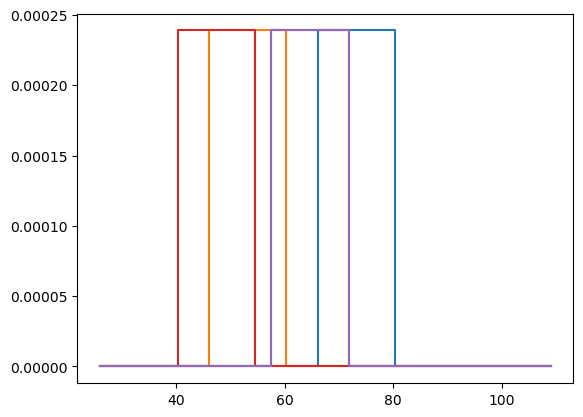

Plug-in Bandwidth Estimated is: 16.874549


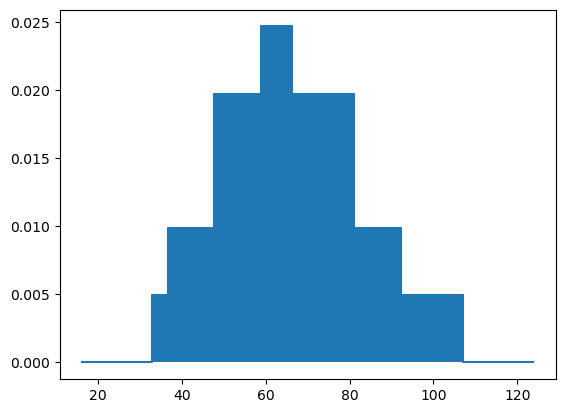

(array([ 16.25090255,  19.95773686,  23.66457117,  27.37140547,
         31.07823978,  34.78507409,  38.49190839,  42.1987427 ,
         45.90557701,  49.61241131,  53.31924562,  57.02607993,
         60.73291423,  64.43974854,  68.14658285,  71.85341715,
         75.56025146,  79.26708577,  82.97392007,  86.68075438,
         90.38758869,  94.09442299,  97.8012573 , 101.50809161,
        105.21492591, 108.92176022, 112.62859453, 116.33542883,
        120.04226314, 123.74909745]),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.0049384 , 0.00987681, 0.00987681, 0.00987681, 0.01975361,
        0.01975361, 0.01975361, 0.02469202, 0.02469202, 0.01975361,
        0.01975361, 0.01975361, 0.01975361, 0.00987681, 0.00987681,
        0.00987681, 0.0049384 , 0.0049384 , 0.0049384 , 0.0049384 ,
        0.        , 0.        , 0.        , 0.        , 0.        ]))

In [133]:
J = 5
X = df['age']
n = len(X)
h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, 30) # Create a grid to plot

for i in range(J):
    I_i = np.abs( x_grid[:,None] - X[i]) < h_u # Broadcast the indicator
    f_i = np.sum(I_i,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_i,where='pre')
plt.show()

kde( df.loc[:J,'age'] )

## Different Kernels
- Instead of using the uniform density for "measurement error", you can use a standard normal/Gaussian:
$$
\hat{f}_h(x) = \dfrac{1}{nh} \sum_{i=1}^n \dfrac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2} \left( \dfrac{x_i-x}{h}\right)^2\right)
$$
with bandwidth plug-in
$$
h = 1.06 \times \text{SD}(X) \times n^{-.2}
$$
- This is the default for plotting software, but it's a choice you should be conscious of
- There is an entire field of **non-parametric estimation** that studies how to estimate densities/distributions this way

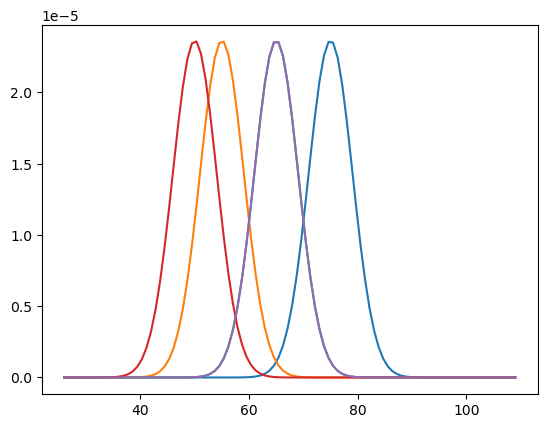

In [134]:
J = 5 # Number of data points to plot
X = df['age']
n = len(X)
h_g = 1.06 * X.std() * n ** (-0.2) # Compute bandwidth
x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, 100) # Create a grid to plot

gauss = lambda z: np.exp( -z**2/2)/np.sqrt(2*np.pi) # Gaussian kernel

f_hat = 0.0 # Storage for our kde plot
for i in range(J):
    K_i = gauss( (x_grid[:,None] - X[i])/h_g)/h_g # Broadcast the indicator
    f_i = np.sum(K_i,axis=1)/(2 * n * h_u) # Compute kde
    f_hat += f_i # Add f_i to the aggregate KDE
    plt.plot(x_grid,f_i)
plt.show()

<Axes: xlabel='age'>

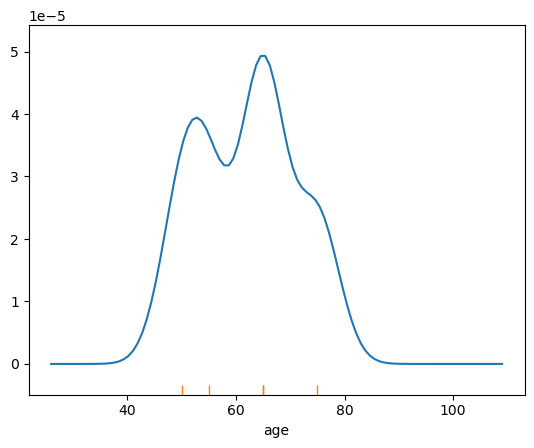

In [123]:
plt.plot(x_grid,f_hat) # Plot the aggregate KDE
sns.rugplot(X[:J]) # Rugplot to visualize data points

Plug-in Bandwidth Estimated is: 4.025331


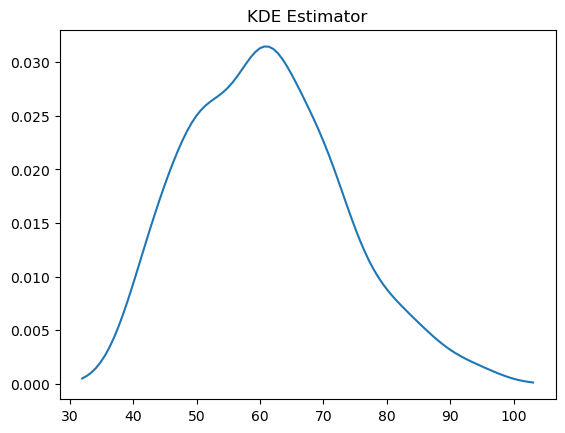

In [ ]:
def kde_g(X, h = 0.0, plot = True):
    X = np.array(X)
    gauss = lambda z: np.exp( -z**2 / 2) / np.sqrt(2 * np.pi) # Gaussian kernel
    n = len(X)
    if h == 0.0:
        h = 1.06 * X.std() * n ** (-0.2) # Compute bandwidth
        print(f'Plug-in Bandwidth Estimated is: {h:2f}')
    x_grid = np.linspace( X.min()-2*h, X.max()+2*h, 100) # Create a grid to plot
    K = gauss( (x_grid[:,None] - X[None,:])/h)/h # Broadcast the indicator
    f_hat = K.mean(axis=1)
    if plot:
        plt.plot(x_grid,f_hat)
        plt.title('KDE Estimator')
        plt.show()
    return x_grid, f_hat, h

X = df['age']
x_grid, f_hat, h = kde_g(X)

<Axes: xlabel='age', ylabel='Density'>

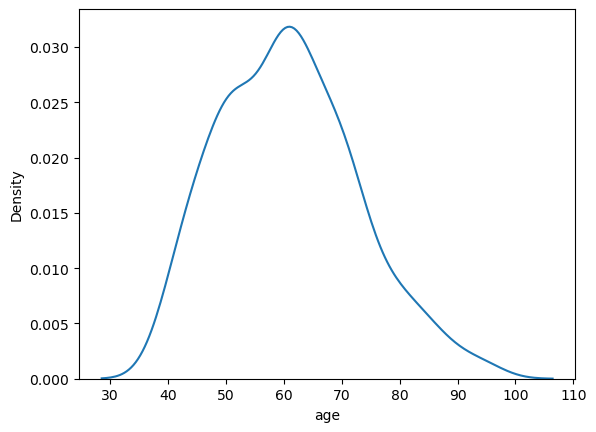

In [137]:
sns.kdeplot(X)

# 2. Bias of the KDE

## ECDF versus KDE
- The ECDF $\hat{F}(x)$ is unbiased: In expectation, it equals the true distribution function, $F(x)$
- The kernel density estimator $\hat{f}_h(x)$ has a more complex relationship with $f(x)$
- **Unless the bandwidth $h$ goes to zero as $n$ gets large, the KDE will not converge to the truth**
- The KDE is a **consistent** but **biased** estimate
- We'll show this by holding the bandwidth constant and increasing the sample size: It won't converge to the normal bell curve

Plug-in Bandwidth Estimated is: 0.533487
Initial bandwidths is:0.53


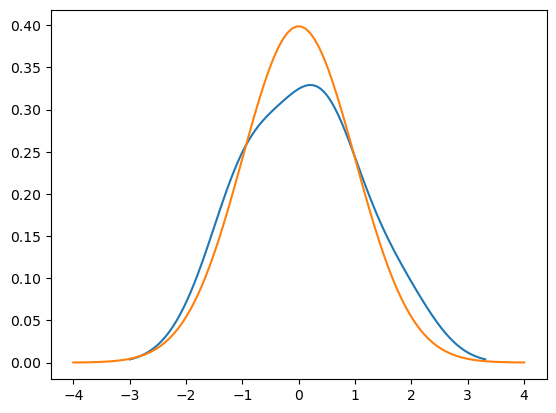

In [138]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 32

gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

samples = rng.standard_normal( size = n) 

# Initial estimate
x_grid, f_hat, h = kde_g(samples,plot=False)
plt.plot(x_grid,f_hat)
plt.plot(grid,bell)
print(f'Initial bandwidths is:{h:.2f}')

Fixed bandwidths is:0.50


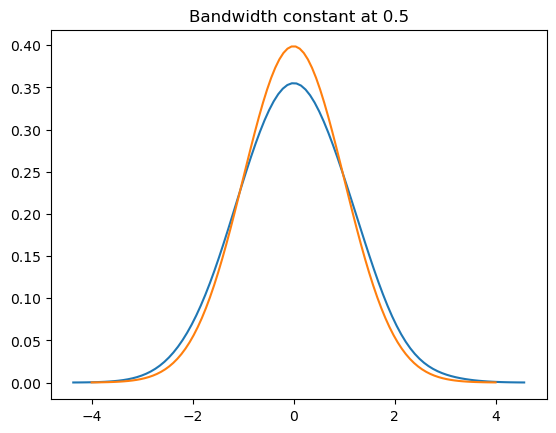

In [139]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 5000

gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

samples = rng.standard_normal( size = n) 

# Initial estimate
x_grid, f_hat, h = kde_g(samples,h=.5,plot=False)
plt.plot(x_grid,f_hat)
plt.title('Bandwidth constant at 0.5')
plt.plot(grid,bell)
print(f'Fixed bandwidths is:{h:.2f}')

Plug-in Bandwidth Estimated is: 0.191914
Floating bandwidths is:0.19


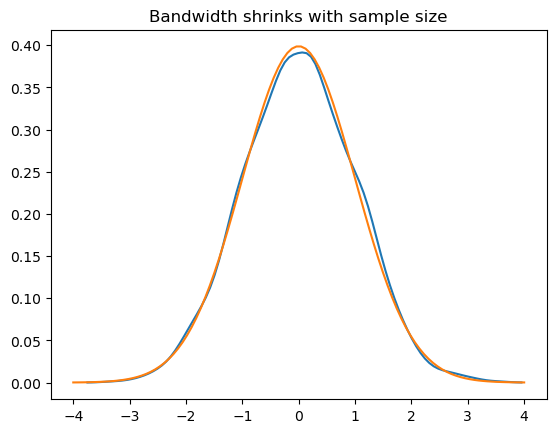

In [141]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 5000 # Sample Size

## Gaussian Curve:
gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

## KDE:
samples = rng.standard_normal( size = n) 
x_grid, f_hat, h = kde_g(samples,plot=False)
plt.plot(x_grid,f_hat)
plt.plot(grid,bell)
plt.title('Bandwidth shrinks with sample size')
print(f'Floating bandwidths is:{h:.2f}')

## What happened?
- We got an initial bandwidth estimate of about $.50$
- For the fixed simulation, the KDE is wrong: Bandwidth doesn't align with the true bell curve
- For the floating simulation, the KDE appoaches the truth: Bandwidth shrinks with the sample to $.19$
- KDE estimators are our first example of an estimator that is **biased** but **consistent**

## KDE as "Slope" of the ECDF
- We know that the derivative of the CDF $F(x)$ is the PDF $f(x)$
- Let's compute the secant of the ECDF, as if we were preparing to take a derivative:
$$
\begin{alignat*}{2}
\dfrac{\hat{F}(x+h)- \hat{F}(x-h)}{2h} &=&  \dfrac{ \frac{1}{n}\sum_{i=1}^n \mathbb{I}\{x_i \le x+h\} - \frac{1}{n}\sum_{i=1}^n\mathbb{I}\{x_i \le x-h\}}{2h} \\
&=& \dfrac{ \sum_{i=1}^n \mathbb{I}\{x_i \le x+h\} - \mathbb{I}\{x_i \le x-h\}}{2nh}
\end{alignat*}
$$
- For a particular $i$, the numerator is 1 whenever $x+h \ge x_i$ and $x_i > x-h$: That's the same as $\mathbb{I}\{ |x_i - x| < h \}$
- Then we have
$$
\dfrac{\sum_{i=1}^n \mathbb{I}\{ |x_i-x| < h\} }{2nh} = \hat{f}_{h}(x)
$$
- The KDE is the secant line of the ECDF


## Expectation of the KDE
- What happens if we take the expectation of the KDE? The ECDF is unbiased, so we know:
$$
\mathbb{E}_X[\hat{f}_{X,h}(x)] = \mathbb{E}_X \left[ \dfrac{\hat{F}_X(x+h)- \hat{F}_X(x-h)}{2h} \right] = \dfrac{F_X(x+h)- F_X(x-h)}{2h}
$$
- This is not quite the derivative of the CDF, which would be the PDF? But if we take the limit with respect to $h$, we get
$$
\lim_{h \rightarrow 0} \mathbb{E}_X[\hat{f}_{X,h}(x)] = F_X'(x)
$$
- This quantity, $F_X'(x)$ is defined as the probability density function $f_X(x)$: The KDE is roughly estimating the PDF, as the bandwidth $h$ goes to zero


## The KDE is Biased, but Consistent
- We know from our earlier calculations that
$$
\lim_{h \rightarrow 0} \mathbb{E}_X[\hat{f}_{X,h}(x)] = F_X'(x)
$$
- But since we are typically using the Silverman plug-in, that $h$ is not zero: It's proportional to $ 1/n^{1/5}$
- The KDE is **biased**: It is not equal to the pdf $f(x)$ in expectation
- But because $h_n \rightarrow 0$ as $n$ gets large, the bias also tends to zero as $h_n\rightarrow 0$
- The KDE is a **consistent estimator** of $f_X(x)$, since the estimate tends to the truth as the sample size gets large

<img src="./src/secant.png" width="750px">